## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
object_name = 'Documents_XVIII_century' # Books / Documents_XVIII_century

In [3]:
if object_name == 'Books':
    real_or_simulated = 'real' #simulated / real / all
    augmentation = False
    augmentation_weights = [0.9, 0.1]
    proportion_of_augmented = 0.25

keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
preprocessing_method = 'logarithm' # normalization / logarithm

columns_to_keep_inks = {
                        'Books': [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'
                                                            ],
    
                        'Konstytucja' : [
                                                 'Al',
                                                 'S',
                                                 'Cr',
                                                 'Mn',
                                                 'Co',
                                                 'Cu',
                                                 'Zn',
                                                 'Pb'
                                                            ]
    
                        }

columns_to_keep_inds = { 
                        'Books' : [
                            
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'
                                                        ],
                        'Konstytucja' : []
    
                        }

In [4]:
data_path = {'Books' : '../data/DANE.xlsx',
             'Documents_XVIII_century' : '../data/Lipiec_2024.xlsx',
             'Konstytucja' : '../data/Lipiec_2024.xlsx'}

results_path = {'Books' : '../results/Books/',
                'Documents_XVIII_century' : '../results/Documents_XVIII_century/',
                'Konstytucja' : '../results/Konstytucja/'}

figures_path = {'Books' : '../results/visualisations/Books/',
                'Documents_XVIII_century' : '../results/visualisations/Documents_XVIII_century/',
                'Konstytucja': '../results/visualisations/Konstytucja/'}

models_path = {'Books' : '../models/Books/',
                'Documents_XVIII_century' : '../models/Documents_XVIII_century/',
                'Konstytucja' : '../models/Konstytucja/'}

1) próbki razem + trzymanie jakiegoś id
2) czyszczenie danych
3) train-test split
4) augmentacja
5) normalizacja
6) ocena jakości

## Loading the data

In [5]:
df = pd.ExcelFile(data_path[object_name])

if object_name == 'Books':
    if real_or_simulated == 'simulated':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    elif real_or_simulated == 'real':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
    elif real_or_simulated == 'all':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

elif object_name == 'Documents_XVIII_century':
    inks_df = df.parse('Arkusz1', header=0, usecols=range(2,29), skiprows=range(3931, 4742))
    inds_df = df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(3931, 4742))
    inds_df.columns = inks_df.columns

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [6]:
inks_df = inks_df.reset_index(drop=False)
inds_df = inds_df.reset_index(drop=False)
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [7]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Keeping track of the records from the same sample

In [8]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

In [9]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df)

### Removing some data

1. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [10]:
inDKs_df = inDKs_df[columns_to_keep_inks[object_name] + columns_to_keep_inds[object_name] + ['Sample_id']]

2. Let's remove rows with missing values.

In [11]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.007888040712468193

In [12]:
inDKs_df.dropna(inplace=True)

### Train test split, datasets, dataloaders

In [13]:
if keep_sample_together:
    
    indices = list(inDKs_df['Sample_id'].unique())
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

### Data augmentation

In [14]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    inks_df_sim = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df_sim = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    inks_df_sim.reset_index(drop=False, inplace=True)
    inds_df_sim.reset_index(drop=False, inplace=True)
    inDKs_df_sim = inds_df_sim.join(inks_df_sim, how='inner', rsuffix='_inks', lsuffix='_inds')
    ids_sim = range(inDKs_df['Sample_id'].max()+1, inDKs_df['Sample_id'].max() + 1 + int(inDKs_df_sim.shape[0]/15))
    inDKs_df_sim['Sample_id'] = np.repeat(ids_sim, 15, axis=0)
    inDKs_df_sim.dropna(inplace=True)
    inDKs_df_sim = inDKs_df_sim[inks_colnames + inds_colnames + ['Sample_id']]

In [15]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    indices_to_mix_real = random.sample(range(X_y_train.shape[0]), 
                                        int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_to_mix_sim = random.sample(range(inDKs_df_sim.shape[0]), 
                                       int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_not_to_mix_real = list(set(range(X_y_train.shape[0])).difference(set(indices_to_mix_real)))
    indices_not_to_mix_sim = list(set(range(inDKs_df_sim.shape[0])).difference(set(indices_to_mix_sim)))

    real_not_to_mix = X_y_train.iloc[indices_not_to_mix_real,:]
    real_to_mix = X_y_train.iloc[indices_to_mix_real,:]
    sim_to_mix = inDKs_df_sim.iloc[indices_to_mix_sim,:]
    real_not_to_mix.reset_index(inplace=True, drop=True)
    real_to_mix.reset_index(inplace=True, drop=True)
    sim_to_mix.reset_index(inplace=True, drop=True)
    X_y_augmented = \
                real_to_mix.loc[:, real_to_mix.columns != 'Sample_id']*augmentation_weights[0] + \
                sim_to_mix.loc[:, sim_to_mix.columns != 'Sample_id']*augmentation_weights[1]
    X_y_augmented['Sample_id_real'] = real_to_mix['Sample_id']
    X_y_augmented['Sample_id_sim'] = sim_to_mix['Sample_id']

    X_y_train = real_not_to_mix

### Creating features and labels matrices

In [16]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']

if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    augmented_real_order = X_y_augmented['Sample_id_real']
    augmented_sim_order = X_y_augmented['Sample_id_sim']

X_train = np.array(X_y_train[columns_to_keep_inds[object_name]].values)
y_train = np.array(X_y_train[columns_to_keep_inks[object_name]].values)
X_val = np.array(X_y_val[columns_to_keep_inds[object_name]].values)
y_val = np.array(X_y_val[columns_to_keep_inks[object_name]].values)
X_test = np.array(X_y_test[columns_to_keep_inds[object_name]].values)
y_test = np.array(X_y_test[columns_to_keep_inks[object_name]].values)

if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    X_augmented = np.array(X_y_augmented[columns_to_keep_inds[object_name]].values)
    y_augmented = np.array(X_y_augmented[columns_to_keep_inks[object_name]].values)

### Normalization / taking logarithm

In [17]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [18]:
if preprocessing_method == 'normalization':
    
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:

        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])

        X_all = (X_all - np.min(X_all, axis=0))/np.std(X_all, axis=0)
        y_all = (y_all - np.min(y_all, axis=0))/np.std(y_all, axis=0)

        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
        y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
        
        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])
        
        X_all = adjusted_log_transform(X_all)
        y_all = adjusted_log_transform(y_all)
        
        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = adjusted_log_transform(X_train)
        y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
elif preprocessing_method == 'logarithm_and_normalization':
    
    #logarithm
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
        
        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])
        
        X_all = adjusted_log_transform(X_all)
        y_all = adjusted_log_transform(y_all)
        
        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = adjusted_log_transform(X_train)
        y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
    #normalization
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:

        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])

        X_all = (X_all - np.min(X_all, axis=0))/np.std(X_all, axis=0)
        y_all = (y_all - np.min(y_all, axis=0))/np.std(y_all, axis=0)

        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
        y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)

/tmp/ipykernel_18996/1324458353.py:2: RuntimeWarning: divide by zero encountered in log
  res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)


In [19]:
#plt.hist(X_val[:,2], bins=100)

### Converting to tensors

In [20]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [21]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    
    X_train = torch.Tensor(np.concatenate([X_train, X_augmented])).to(device)
    y_train = torch.Tensor(np.concatenate([y_train, y_augmented])).to(device)
    
else:
    
    X_train = torch.Tensor(X_train).to(device)
    y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [22]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [23]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [24]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [25]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [27]:
dropout_prob = 0.02

class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 128),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [28]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): Dropout(p=0.02, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): Dropout(p=0.02, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=128, bias=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): Dropout(p=0.02, inplace=False)
    (11): ReLU()
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): Dropout(p=0.02, inplace=False)
    (14): ReLU()
    (15): Linear(in_features=32, out_features=8, bias=True)
  )
)


In [29]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

1/2, 1/4, 1/8, 1/40, 1/40, 1/40, 1/40, 1/40

1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40


In [30]:
#weights = torch.tensor([1/2,1/4,1/8,1/40,1/40,1/40,1/40,1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/3,1/3,1/18,1/18,1/18,1/18,1/18,1/18]).unsqueeze(1).to(device)
weights = torch.tensor([1/8,1/8,1/8,1/8,1/8,1/8,1/8,1/8]).unsqueeze(1).to(device)
#weights = torch.tensor([1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20]).unsqueeze(1).to(device)


class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [31]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 2.8669427732626596 test 1.5417064423698645
EPOCH 2:
LOSS train 1.460438812772433 test 1.2373092687825362
EPOCH 3:
LOSS train 1.257355958223343 test 1.159995820647631
EPOCH 4:
LOSS train 1.1917496869961421 test 1.0964064259529114
EPOCH 5:
LOSS train 1.144738992055257 test 1.0472544750976256
EPOCH 6:
LOSS train 1.1130065768957138 test 1.0097145609977918
EPOCH 7:
LOSS train 1.0756858512759209 test 0.9841207751425413
EPOCH 8:
LOSS train 1.0435372119148572 test 0.9409930148567909
EPOCH 9:
LOSS train 1.0077937642733257 test 0.9121548776408801
EPOCH 10:
LOSS train 0.9780816187461218 test 0.858114256398036
EPOCH 11:
LOSS train 0.9442076086997986 test 0.8450647171265804
EPOCH 12:
LOSS train 0.9205640256404877 test 0.8770574835928587
EPOCH 13:
LOSS train 0.9238811383644739 test 0.803099925137101
EPOCH 14:
LOSS train 0.8843779315551122 test 0.7968504399573191
EPOCH 15:
LOSS train 0.8744137858351072 test 0.7723936360394343
EPOCH 16:
LOSS train 0.8580531378587087 test 0.75768358

LOSS train 0.5564847439527512 test 0.5007400935064905
EPOCH 130:
LOSS train 0.5615534906586012 test 0.501318702184428
EPOCH 131:
LOSS train 0.5592925871411959 test 0.5074340865703729
EPOCH 132:
LOSS train 0.5581804265578588 test 0.49773321128923165
EPOCH 133:
LOSS train 0.5532625839114189 test 0.49494423087170486
EPOCH 134:
LOSS train 0.5531774746874968 test 0.4946431584535883
EPOCH 135:
LOSS train 0.5586898798743883 test 0.5061258210297197
EPOCH 136:
LOSS train 0.5571818016469479 test 0.5039025649976654
EPOCH 137:
LOSS train 0.5514678085843722 test 0.4953850291562386
EPOCH 138:
LOSS train 0.5469343662261963 test 0.4909220123541279
EPOCH 139:
LOSS train 0.552378053466479 test 0.4908040142065057
EPOCH 140:
LOSS train 0.5499834530055523 test 0.4985140315657242
EPOCH 141:
LOSS train 0.5458918549120426 test 0.48947227448664415
EPOCH 142:
LOSS train 0.5459386159976324 test 0.48845070557640147
EPOCH 143:
LOSS train 0.543981154759725 test 0.48594098035781047
EPOCH 144:
LOSS train 0.5466516216

LOSS train 0.46650779992341995 test 0.44056729034678294
EPOCH 256:
LOSS train 0.47252869978547096 test 0.4369911558693036
EPOCH 257:
LOSS train 0.46920177713036537 test 0.4466712127390962
EPOCH 258:
LOSS train 0.47000716874996823 test 0.42918248928624847
EPOCH 259:
LOSS train 0.4685249291360378 test 0.4310442149916138
EPOCH 260:
LOSS train 0.4665599428117275 test 0.428892367480466
EPOCH 261:
LOSS train 0.4665035692354043 test 0.4350600309037627
EPOCH 262:
LOSS train 0.46900180106361705 test 0.4262728753882723
EPOCH 263:
LOSS train 0.4626694569985072 test 0.43160867839612255
EPOCH 264:
LOSS train 0.46797720342874527 test 0.4319464083506893
EPOCH 265:
LOSS train 0.46175549427668255 test 0.4299199134457187
EPOCH 266:
LOSS train 0.4638325311243534 test 0.4334575783245456
EPOCH 267:
LOSS train 0.46222369621197384 test 0.43364735369422497
EPOCH 268:
LOSS train 0.46428241084019345 test 0.43796153784161196
EPOCH 269:
LOSS train 0.4718196814258893 test 0.4243374808770724
EPOCH 270:
LOSS train 0

LOSS train 0.40910770992438 test 0.39386985144363
EPOCH 381:
LOSS train 0.4199100186427434 test 0.3915886340451737
EPOCH 382:
LOSS train 0.4110649600625038 test 0.40314905588309735
EPOCH 383:
LOSS train 0.42065973331530887 test 0.3968586753549484
EPOCH 384:
LOSS train 0.413540318608284 test 0.39781995288855754
EPOCH 385:
LOSS train 0.414542352159818 test 0.3943967054304786
EPOCH 386:
LOSS train 0.41123630354801816 test 0.4026689550313048
EPOCH 387:
LOSS train 0.4183104025820891 test 0.40379205721960615
EPOCH 388:
LOSS train 0.4073912439246972 test 0.40052394456425916
EPOCH 389:
LOSS train 0.4090454528729121 test 0.3918687705107224
EPOCH 390:
LOSS train 0.4118243431051572 test 0.39503137760045814
EPOCH 391:
LOSS train 0.4101915893455346 test 0.3934340742983115
EPOCH 392:
LOSS train 0.4163150414824486 test 0.3981408813244257
EPOCH 393:
LOSS train 0.4109486962358157 test 0.38842638004246427
EPOCH 394:
LOSS train 0.4091629907488823 test 0.3922203209920762
EPOCH 395:
LOSS train 0.4071356418

LOSS train 0.3739355280995369 test 0.3690780033082343
EPOCH 507:
LOSS train 0.37617968892057735 test 0.36871073856796976
EPOCH 508:
LOSS train 0.3746950551867485 test 0.3700637058023459
EPOCH 509:
LOSS train 0.3764643420775731 test 0.3713212524028734
EPOCH 510:
LOSS train 0.3717129019399484 test 0.3721200522406934
EPOCH 511:
LOSS train 0.36004092916846275 test 0.3630166287778471
EPOCH 512:
LOSS train 0.3710842529932658 test 0.37249118823070937
EPOCH 513:
LOSS train 0.3824103797475497 test 0.374021628772219
EPOCH 514:
LOSS train 0.3728545444707076 test 0.36308761361117164
EPOCH 515:
LOSS train 0.3734210319817066 test 0.3734822763761458
EPOCH 516:
LOSS train 0.3701111376285553 test 0.36364053479371927
EPOCH 517:
LOSS train 0.37585057442386943 test 0.36175419057542696
EPOCH 518:
LOSS train 0.3751477723320325 test 0.3854372354097282
EPOCH 519:
LOSS train 0.37745875244339305 test 0.3638851684799943
EPOCH 520:
LOSS train 0.37224279592434567 test 0.36409446732308237
EPOCH 521:
LOSS train 0.36

...

LOSS train 0.2250641950716575 test 0.30137265533352126
EPOCH 4446:
LOSS train 0.22226374968886375 test 0.2994283213990812
EPOCH 4447:
LOSS train 0.21594158125420412 test 0.30116999628920205
EPOCH 4448:
LOSS train 0.22074279623727003 test 0.2985925927574818
EPOCH 4449:
LOSS train 0.2211405343065659 test 0.2983553490266204
EPOCH 4450:
LOSS train 0.2247225989898046 test 0.2987842780163464
EPOCH 4451:
LOSS train 0.2169126719236374 test 0.3014306324076576
EPOCH 4452:
LOSS train 0.22040648696323237 test 0.300811285580389
EPOCH 4453:
LOSS train 0.23101672592262426 test 0.29716893197557864
EPOCH 4454:
LOSS train 0.21586190784970918 test 0.2955633236910097
EPOCH 4455:
LOSS train 0.22290633680919805 test 0.30189470226690174
EPOCH 4456:
LOSS train 0.22344357458253702 test 0.2993690633021104
EPOCH 4457:
LOSS train 0.23076162611444792 test 0.3010588174466139
EPOCH 4458:
LOSS train 0.2174586821347475 test 0.29979257165850737
EPOCH 4459:
LOSS train 0.22093979083001614 test 0.3017978955729363
EPOCH 44

LOSS train 0.22460355423390865 test 0.2993453994693282
EPOCH 4569:
LOSS train 0.2246681588391463 test 0.3026410028127332
EPOCH 4570:
LOSS train 0.22668310875693956 test 0.3030280633000418
EPOCH 4571:
LOSS train 0.22114191638926664 test 0.30199986671818757
EPOCH 4572:
LOSS train 0.2250390083839496 test 0.3059014040119469
EPOCH 4573:
LOSS train 0.22739740771551928 test 0.30270815755656133
EPOCH 4574:
LOSS train 0.2267245016992092 test 0.30195758670683087
EPOCH 4575:
LOSS train 0.23185637965798378 test 0.302174830068858
EPOCH 4576:
LOSS train 0.22694862882296243 test 0.30276523779910536
EPOCH 4577:
LOSS train 0.21995708222190538 test 0.3031975985309348
EPOCH 4578:
LOSS train 0.22508717825015387 test 0.30289428082184916
EPOCH 4579:
LOSS train 0.2136921932299932 test 0.30014498894609126
EPOCH 4580:
LOSS train 0.22471417983373007 test 0.29873975706453887
EPOCH 4581:
LOSS train 0.21951572162409624 test 0.302337759235635
EPOCH 4582:
LOSS train 0.2227185188482205 test 0.29983479780675126
EPOCH 

LOSS train 0.21933918818831444 test 0.303347718000603
EPOCH 4692:
LOSS train 0.2188602058837811 test 0.300351244633301
EPOCH 4693:
LOSS train 0.22078003423909345 test 0.2992143087098614
EPOCH 4694:
LOSS train 0.22259478643536568 test 0.29725480275629806
EPOCH 4695:
LOSS train 0.2211152631789446 test 0.2973401813340397
EPOCH 4696:
LOSS train 0.22232165870567164 test 0.29900174551781933
EPOCH 4697:
LOSS train 0.22098739134768644 test 0.298252840095128
EPOCH 4698:
LOSS train 0.22102736433347067 test 0.2974956997523132
EPOCH 4699:
LOSS train 0.22590100020170212 test 0.3024445838764883
EPOCH 4700:
LOSS train 0.21608596170941988 test 0.2971629492805745
EPOCH 4701:
LOSS train 0.21988524496555328 test 0.29805940709339507
EPOCH 4702:
LOSS train 0.21873830383022627 test 0.29840242671641787
EPOCH 4703:
LOSS train 0.21771839261054993 test 0.29632951967838483
EPOCH 4704:
LOSS train 0.22193157424529394 test 0.30074934740975884
EPOCH 4705:
LOSS train 0.22461653500795364 test 0.29963799643210876
EPOCH

LOSS train 0.2166572387019793 test 0.29796026805597237
EPOCH 4815:
LOSS train 0.2277490465591351 test 0.3013559264209695
EPOCH 4816:
LOSS train 0.21929823669294515 test 0.2965952972340851
EPOCH 4817:
LOSS train 0.22035294709106287 test 0.30489279825345444
EPOCH 4818:
LOSS train 0.21729368654390177 test 0.2960741867807527
EPOCH 4819:
LOSS train 0.21138078284760317 test 0.2988763394627529
EPOCH 4820:
LOSS train 0.22008581024905047 test 0.29828730990365143
EPOCH 4821:
LOSS train 0.22460217028856277 test 0.29599671100003594
EPOCH 4822:
LOSS train 0.22362945104638735 test 0.2955891532604224
EPOCH 4823:
LOSS train 0.22201851072410742 test 0.2986365891313419
EPOCH 4824:
LOSS train 0.2198937168965737 test 0.29566233438697576
EPOCH 4825:
LOSS train 0.22167676004270712 test 0.3002940290051584
EPOCH 4826:
LOSS train 0.21783697605133057 test 0.2991646008310983
EPOCH 4827:
LOSS train 0.21604299917817116 test 0.2960008945814215
EPOCH 4828:
LOSS train 0.21585790067911148 test 0.30031422428610044
EPOC

LOSS train 0.2191590964794159 test 0.2996462378581174
EPOCH 4938:
LOSS train 0.21774382206300893 test 0.29867183143884324
EPOCH 4939:
LOSS train 0.2141104775170485 test 0.2961227634428785
EPOCH 4940:
LOSS train 0.21490124488870302 test 0.29712199715782817
EPOCH 4941:
LOSS train 0.2212249618023634 test 0.2978435905141135
EPOCH 4942:
LOSS train 0.2172920536249876 test 0.2977158714226232
EPOCH 4943:
LOSS train 0.2212685371438662 test 0.2973954036221481
EPOCH 4944:
LOSS train 0.21930524334311485 test 0.295524383960244
EPOCH 4945:
LOSS train 0.2204203406969706 test 0.2978315970785916
EPOCH 4946:
LOSS train 0.22299393018086752 test 0.29535374918560947
EPOCH 4947:
LOSS train 0.21829750885566077 test 0.29907034569615737
EPOCH 4948:
LOSS train 0.22145912237465382 test 0.29714215722040105
EPOCH 4949:
LOSS train 0.22215711449583372 test 0.30003821509794737
EPOCH 4950:
LOSS train 0.21926933651169142 test 0.2972217768096389
EPOCH 4951:
LOSS train 0.2224164636184772 test 0.3003309815062735
EPOCH 495

In [31]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 3.1801145871480307 test 2.6124079996546112
EPOCH 2:
LOSS train 1.7814880510171254 test 1.2876359921747291
EPOCH 3:
LOSS train 1.265001450975736 test 1.1299684093984272
EPOCH 4:
LOSS train 1.1788953493038814 test 1.070979447661302
EPOCH 5:
LOSS train 1.135903591910998 test 1.0320504543208158
EPOCH 6:
LOSS train 1.0912572642167409 test 1.0004943481339856
EPOCH 7:
LOSS train 1.0625241448481877 test 0.9593527617668494
EPOCH 8:
LOSS train 1.0220645144581795 test 0.920121450276329
EPOCH 9:
LOSS train 0.9832091604669889 test 0.887808651903883
EPOCH 10:
LOSS train 0.9449840063850085 test 0.8617055482119322
EPOCH 11:
LOSS train 0.9285170137882233 test 0.8239953051702334
EPOCH 12:
LOSS train 0.9005351314942042 test 0.809176664050191
EPOCH 13:
LOSS train 0.8885288710395495 test 0.7951034434309755
EPOCH 14:
LOSS train 0.8736985797683398 test 0.783599445015001
EPOCH 15:
LOSS train 0.8667047793666521 test 0.7692892497839072
EPOCH 16:
LOSS train 0.8587682271997134 test 0.758788499

LOSS train 0.5965808555483818 test 0.531138356377681
EPOCH 131:
LOSS train 0.5898219446341196 test 0.5273317019408329
EPOCH 132:
LOSS train 0.5942918285727501 test 0.5307258203698274
EPOCH 133:
LOSS train 0.5926122243205706 test 0.5255477759882043
EPOCH 134:
LOSS train 0.5859212304155031 test 0.524755015802307
EPOCH 135:
LOSS train 0.5852958187460899 test 0.5254148336818967
EPOCH 136:
LOSS train 0.5894782145818075 test 0.5246143168801298
EPOCH 137:
LOSS train 0.5874768843253454 test 0.5165616916127693
EPOCH 138:
LOSS train 0.5854094276825587 test 0.5299749111579014
EPOCH 139:
LOSS train 0.5856551801164945 test 0.5283103590059357
EPOCH 140:
LOSS train 0.5820563038190206 test 0.5242231013788244
EPOCH 141:
LOSS train 0.5864192123214403 test 0.5290938281980463
EPOCH 142:
LOSS train 0.5873641048868498 test 0.5562863447700556
EPOCH 143:
LOSS train 0.5875634203354517 test 0.524285207017492
EPOCH 144:
LOSS train 0.5807949230074883 test 0.5247575319978671
EPOCH 145:
LOSS train 0.585978123048941

LOSS train 0.5263861815134684 test 0.47519285787756627
EPOCH 258:
LOSS train 0.5236764525373777 test 0.4743153052356763
EPOCH 259:
LOSS train 0.5186102204024792 test 0.4729648540002795
EPOCH 260:
LOSS train 0.5191702743371328 test 0.47387842050786966
EPOCH 261:
LOSS train 0.5225474449495474 test 0.4816291203934413
EPOCH 262:
LOSS train 0.5155102151135603 test 0.47402006686478854
EPOCH 263:
LOSS train 0.5187976844608784 test 0.47235665792322307
EPOCH 264:
LOSS train 0.5237577694157759 test 0.4795711866080379
EPOCH 265:
LOSS train 0.5184097997844219 test 0.4727939923808743
EPOCH 266:
LOSS train 0.519401869426171 test 0.471956637300742
EPOCH 267:
LOSS train 0.5233035696049532 test 0.4767509652013198
EPOCH 268:
LOSS train 0.5201237325867017 test 0.4737194452062249
EPOCH 269:
LOSS train 0.5179225616157055 test 0.47497534329501484
EPOCH 270:
LOSS train 0.5154823785026869 test 0.4709922018198248
EPOCH 271:
LOSS train 0.5132088040312132 test 0.4703083427380293
EPOCH 272:
LOSS train 0.515709734

LOSS train 0.4664679641524951 test 0.43735768594535496
EPOCH 383:
LOSS train 0.47074296946326893 test 0.4497519920579134
EPOCH 384:
LOSS train 0.4779096667965253 test 0.4395422233203665
EPOCH 385:
LOSS train 0.4756280469397704 test 0.43583099770354916
EPOCH 386:
LOSS train 0.4738403980930646 test 0.4354866820145876
EPOCH 387:
LOSS train 0.47246064866582554 test 0.43457498850453735
EPOCH 388:
LOSS train 0.4695466222862403 test 0.4340003121848672
EPOCH 389:
LOSS train 0.4752545890708764 test 0.44542193377533784
EPOCH 390:
LOSS train 0.47398290038108826 test 0.4426652121716776
EPOCH 391:
LOSS train 0.468110849459966 test 0.43897078720766763
EPOCH 392:
LOSS train 0.4619063660502434 test 0.43973489599006294
EPOCH 393:
LOSS train 0.4708407086630662 test 0.4422437791786133
EPOCH 394:
LOSS train 0.46999509632587433 test 0.4330252126875596
EPOCH 395:
LOSS train 0.47018369287252426 test 0.43548568813999494
EPOCH 396:
LOSS train 0.4683471731841564 test 0.44241590213469967
EPOCH 397:
LOSS train 0.

LOSS train 0.44195546582341194 test 0.41681698876199047
EPOCH 508:
LOSS train 0.44190770015120506 test 0.4205434077175764
EPOCH 509:
LOSS train 0.43736236294110614 test 0.4183982068106341
EPOCH 510:
LOSS train 0.434657484292984 test 0.4158402712650788
EPOCH 511:
LOSS train 0.447135570148627 test 0.415180932714771
EPOCH 512:
LOSS train 0.43559350694219273 test 0.4147781956558808
EPOCH 513:
LOSS train 0.43576836834351224 test 0.41757169685856654
EPOCH 514:
LOSS train 0.44062068810065586 test 0.41818861718256123
EPOCH 515:
LOSS train 0.4319570412238439 test 0.4143544092594813
EPOCH 516:
LOSS train 0.43336184819539386 test 0.4143882104315055
EPOCH 517:
LOSS train 0.4333638983468215 test 0.4130637789035264
EPOCH 518:
LOSS train 0.4362316355109215 test 0.41462853857913073
EPOCH 519:
LOSS train 0.4377925172448158 test 0.4164753347851145
EPOCH 520:
LOSS train 0.43262933070460957 test 0.4125559328759137
EPOCH 521:
LOSS train 0.43721073617537815 test 0.41438742820880353
EPOCH 522:
LOSS train 0.4

...

LOSS train 0.281554385398825 test 0.33524694888752243
EPOCH 4452:
LOSS train 0.2850883516172568 test 0.3387583399970944
EPOCH 4453:
LOSS train 0.2769936801244815 test 0.3358202307572923
EPOCH 4454:
LOSS train 0.27909308796127635 test 0.3318151597310908
EPOCH 4455:
LOSS train 0.27423774637281895 test 0.33775599598693545
EPOCH 4456:
LOSS train 0.2750527299940586 test 0.3334076277423555
EPOCH 4457:
LOSS train 0.28246981961031753 test 0.3317973168120743
EPOCH 4458:
LOSS train 0.28534319748481113 test 0.329841334015322
EPOCH 4459:
LOSS train 0.28219045015672845 test 0.33115641364225973
EPOCH 4460:
LOSS train 0.2860534315307935 test 0.33199327469168183
EPOCH 4461:
LOSS train 0.2813653399546941 test 0.33672782597155904
EPOCH 4462:
LOSS train 0.2799613190193971 test 0.3326156565565138
EPOCH 4463:
LOSS train 0.2791469519337018 test 0.33239522037750635
EPOCH 4464:
LOSS train 0.28980437728265923 test 0.3367883646467175
EPOCH 4465:
LOSS train 0.28707774356007576 test 0.33324068752418345
EPOCH 4466

LOSS train 0.2889643193533023 test 0.3277981121987104
EPOCH 4575:
LOSS train 0.2823938212047021 test 0.3302584991711072
EPOCH 4576:
LOSS train 0.2793059380104144 test 0.329611709106618
EPOCH 4577:
LOSS train 0.28288322252531845 test 0.33050699108600234
EPOCH 4578:
LOSS train 0.2839574894557397 test 0.3304014189169766
EPOCH 4579:
LOSS train 0.27088146284222603 test 0.3308047484981899
EPOCH 4580:
LOSS train 0.28231444396078587 test 0.3310692221762087
EPOCH 4581:
LOSS train 0.2887680468459924 test 0.3338752963249691
EPOCH 4582:
LOSS train 0.2878706846386194 test 0.3278645063577554
EPOCH 4583:
LOSS train 0.2815953151633342 test 0.3304411024763607
EPOCH 4584:
LOSS train 0.2904880332450072 test 0.3311169543627363
EPOCH 4585:
LOSS train 0.2797796117762725 test 0.32994826826395895
EPOCH 4586:
LOSS train 0.2825554454078277 test 0.3313221488581636
EPOCH 4587:
LOSS train 0.27587249005834263 test 0.3308041280520459
EPOCH 4588:
LOSS train 0.2764301598072052 test 0.33165556588826267
EPOCH 4589:
LOSS

LOSS train 0.27672633652885753 test 0.3340411682440302
EPOCH 4699:
LOSS train 0.28494076430797577 test 0.3316692983047702
EPOCH 4700:
LOSS train 0.28238044244547683 test 0.3312071280563489
EPOCH 4701:
LOSS train 0.2790168573458989 test 0.32930581539697373
EPOCH 4702:
LOSS train 0.2820304352790117 test 0.335137661109177
EPOCH 4703:
LOSS train 0.2817103086660306 test 0.33099432224159436
EPOCH 4704:
LOSS train 0.28505928193529445 test 0.331357406557466
EPOCH 4705:
LOSS train 0.2799489926546812 test 0.3321770323001039
EPOCH 4706:
LOSS train 0.2845990030715863 test 0.3369504138621
EPOCH 4707:
LOSS train 0.2767813454071681 test 0.3341603498121676
EPOCH 4708:
LOSS train 0.285703315710028 test 0.3303402004797871
EPOCH 4709:
LOSS train 0.2769172204037507 test 0.3307393563484343
EPOCH 4710:
LOSS train 0.2827574070543051 test 0.3347775668466511
EPOCH 4711:
LOSS train 0.27597716078162193 test 0.33562585507619835
EPOCH 4712:
LOSS train 0.27936122256020707 test 0.332562121045513
EPOCH 4713:
LOSS tra

LOSS train 0.281195817515254 test 0.3291133285662493
EPOCH 4822:
LOSS train 0.27961401641368866 test 0.33331937826023655
EPOCH 4823:
LOSS train 0.2875377895931403 test 0.3319959039117854
EPOCH 4824:
LOSS train 0.2866033961375554 test 0.3336366566043251
EPOCH 4825:
LOSS train 0.2762296963483095 test 0.33188738799353057
EPOCH 4826:
LOSS train 0.280237744251887 test 0.33053352631695376
EPOCH 4827:
LOSS train 0.2815307881683111 test 0.3280240383572303
EPOCH 4828:
LOSS train 0.27944328635931015 test 0.3299968651715571
EPOCH 4829:
LOSS train 0.27393848324815434 test 0.32936097593767905
EPOCH 4830:
LOSS train 0.2780641224235296 test 0.3344116192907095
EPOCH 4831:
LOSS train 0.2814986873418093 test 0.33149674118615874
EPOCH 4832:
LOSS train 0.2831732388585806 test 0.3311921336993766
EPOCH 4833:
LOSS train 0.27457390042642754 test 0.33010622387809246
EPOCH 4834:
LOSS train 0.2813944003234307 test 0.33160132146980137
EPOCH 4835:
LOSS train 0.28488527548809844 test 0.3293108080507089
EPOCH 4836:


LOSS train 0.2821177902321021 test 0.3315829138586728
EPOCH 4945:
LOSS train 0.2803284004330635 test 0.33191922432738236
EPOCH 4946:
LOSS train 0.2800407738735278 test 0.33113359863559405
EPOCH 4947:
LOSS train 0.280749316016833 test 0.32960701414627525
EPOCH 4948:
LOSS train 0.2850207568456729 test 0.33265943051568975
EPOCH 4949:
LOSS train 0.27211725277205306 test 0.3365033873298611
EPOCH 4950:
LOSS train 0.2798727713525295 test 0.32828571060108835
EPOCH 4951:
LOSS train 0.27995268255472183 test 0.3301780403133195
EPOCH 4952:
LOSS train 0.2774440950403611 test 0.3325850928112482
EPOCH 4953:
LOSS train 0.284200357273221 test 0.3336269605887624
EPOCH 4954:
LOSS train 0.2867194935679436 test 0.32800362020759627
EPOCH 4955:
LOSS train 0.28478184280296165 test 0.3288776220824474
EPOCH 4956:
LOSS train 0.2872258039812247 test 0.33191965658494677
EPOCH 4957:
LOSS train 0.27189716572562855 test 0.3325119511599724
EPOCH 4958:
LOSS train 0.2816951076189677 test 0.3280674499900868
EPOCH 4959:
L

In [31]:
##############################################################################

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

In [32]:
%matplotlib notebook

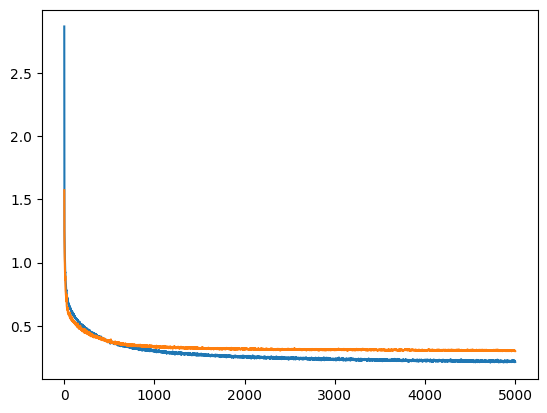

In [32]:
#Documents
#Logarithm
#No augmentation
#No keeping one sample together
# layers 8, 32, 64, 128, 64, 32, 8
#batch size = 100
#Bigger network (64 neurons max)
#lr=0.001
#dropout =0.02

plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.01

## Prediction on test set

In [33]:
model.eval()
running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [34]:
lab

tensor([[ 0.6814, -3.8429, -7.3168,  ..., -2.0901, -5.5168, -0.8327],
        [ 1.7116, -4.4546, -7.4808,  ..., -1.2107, -5.7975, -1.4870],
        [ 1.7433, -3.2536, -7.8672,  ..., -4.1254, -3.4859, -2.4003],
        ...,
        [ 1.5180, -2.1008, -6.8141,  ..., -3.6722, -4.1360,  0.2913],
        [-0.0894, -3.8682, -7.6653,  ..., -1.7766, -5.5490, -0.9989],
        [-0.3599, -5.9045, -7.8310,  ...,  1.1395, -2.5659, -0.6577]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [35]:
out

tensor([[ 0.6767, -3.8089, -7.5580,  ..., -1.5291, -5.6303, -0.7405],
        [ 1.6747, -4.2180, -7.8939,  ..., -1.1820, -5.5353, -1.4872],
        [ 1.5902, -3.3344, -7.9289,  ..., -4.0447, -3.4803, -2.5202],
        ...,
        [ 0.4071, -4.7296, -8.2098,  ..., -3.9255, -3.7940,  0.6235],
        [-0.2387, -3.8846, -7.6748,  ..., -1.7721, -5.7401, -1.2965],
        [-0.5679, -5.6508, -7.9735,  ...,  1.1138, -2.8448, -0.6404]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [36]:
res

tensor([[4.6910e-03, 3.4019e-02, 2.4120e-01,  ..., 5.6099e-01, 1.1346e-01,
         9.2197e-02],
        [3.6871e-02, 2.3657e-01, 4.1308e-01,  ..., 2.8720e-02, 2.6222e-01,
         2.0325e-04],
        [1.5315e-01, 8.0735e-02, 6.1675e-02,  ..., 8.0721e-02, 5.5773e-03,
         1.1988e-01],
        ...,
        [1.1109e+00, 2.6288e+00, 1.3957e+00,  ..., 2.5324e-01, 3.4198e-01,
         3.3225e-01],
        [1.4926e-01, 1.6428e-02, 9.4304e-03,  ..., 4.4814e-03, 1.9110e-01,
         2.9763e-01],
        [2.0803e-01, 2.5370e-01, 1.4257e-01,  ..., 2.5700e-02, 2.7896e-01,
         1.7226e-02]], device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [37]:
torch.mean(res, axis=0) 

tensor([0.2345, 0.2530, 0.3970, 0.1920, 0.2424, 0.2505, 0.2980, 0.3003],
       device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [38]:
torch.mean(res)

tensor(0.2710, device='cuda:0', grad_fn=<MeanBackward0>)

## Saving the model

In [39]:
import time
ts = time.time()
import datetime
now = datetime.datetime.fromtimestamp(ts).strftime('%Y_%m_%d_%H_%M_%S')

torch.save(model.state_dict(), models_path[object_name]+'model_regression_'+now)

### Visualisations

In [46]:
dim_nr = 3
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

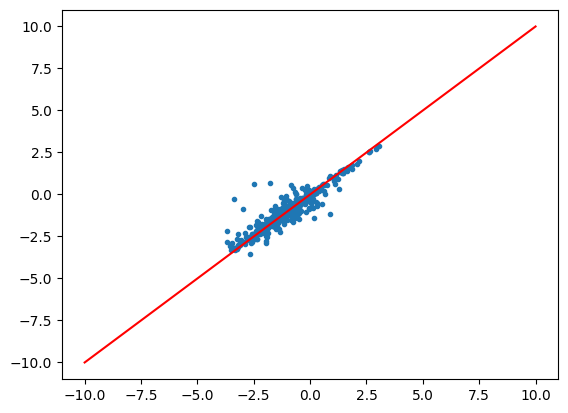

In [47]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [-10, 10],[-10, 10], 'red' )

## Quality of prediction: closest points

#### Creating df with means of classes

In [48]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [49]:
train_val_df = pd.DataFrame(y_train.cpu())
train_val_df = pd.concat([train_val_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_df.columns = elements_names
train_val_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_df.reset_index(drop=True, inplace=True)

In [50]:
mean_df = train_val_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)
    
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_18996/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_18996/649964028.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_18996/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

#### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [51]:
y_test_df = pd.DataFrame(y_test.cpu())
y_test_df.columns = elements_names
y_test_df.insert(0, 'Sample_id', test_order)
y_test_df.reset_index(drop=True, inplace=True)

In [52]:
closest = []
for i in range(y_test_df.shape[0]):
    which_row = (abs(y_test_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [53]:
len(closest)

780

In [54]:
y_test_df['Closest'] = closest

In [55]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] 

724

In [56]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] / len(closest)

0.9282051282051282

#### Now let's check if it works for the neural network's output.

In [57]:
model.eval()
outputs = model(X_test)

In [58]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Real sample_id', test_order)
outputs_df.reset_index(drop=True, inplace=True)

In [59]:
closest = []
for i in range(outputs_df.shape[0]):
    which_row = (abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [60]:
len(closest)

780

In [61]:
outputs_df['Closest'] = closest

In [62]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

624

In [63]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0] / len(closest)

0.8

## Quality of prediction: confidence intervals

In [64]:
model.eval()
outputs = model(X_test)

In [65]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [66]:
all_data_df = pd.DataFrame(y_train.cpu())
all_data_df = pd.concat([all_data_df, 
                        pd.DataFrame(y_val.cpu())])
all_data_df.columns = elements_names
all_data_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
all_data_df.reset_index(drop=True, inplace=True)

In [67]:
min_max_df = all_data_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
        
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
max_df['Sample_id'] = min_max_df['Sample_id']
min_df = min_max_df.iloc[:,1+len(elements_names):]
min_df['Sample_id'] = min_max_df['Sample_id']

/tmp/ipykernel_18996/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_18996/3264826654.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_18996/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

In [68]:
mean_sd_df = all_data_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
upper_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)
lower_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

/tmp/ipykernel_18996/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_18996/2008320981.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_18996/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

In [69]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > \
                    np.array(min_df.loc[min_df['Sample_id'] == sample_id, min_df.columns != 'Sample_id'])
    
    less_than_max = test_example.cpu().detach().numpy() < \
                    np.array(max_df.loc[max_df['Sample_id'] == sample_id, max_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [70]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > \
    np.array(lower_bound_df.loc[lower_bound_df['Sample_id'] == sample_id, lower_bound_df.columns != 'Sample_id'])
    
    less = test_example.cpu().detach().numpy() < \
    np.array(upper_bound_df.loc[upper_bound_df['Sample_id'] == sample_id, upper_bound_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

In [71]:
elements_names

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb']

Percentage of points inside mean +- 2 standard deviations interval:

In [72]:
np.array(sd_res_list).mean()

0.7341346153846153

On consecutive coordinates:

In [73]:
np.array(sd_res_list).mean(0)

array([[0.81410256, 0.77948718, 0.85512821, 0.66153846, 0.66923077,
        0.64358974, 0.72564103, 0.72435897]])

Percentage of points inside min-max interval:

In [74]:
np.array(min_max_res_list).mean()

0.6567307692307692

On consecutive coordinates:

In [75]:
np.array(min_max_res_list).mean(0)

array([[0.72820513, 0.71025641, 0.79487179, 0.59102564, 0.58974359,
        0.54230769, 0.6474359 , 0.65      ]])

### Visualisations of mean +- 2 * standard deviation intervals

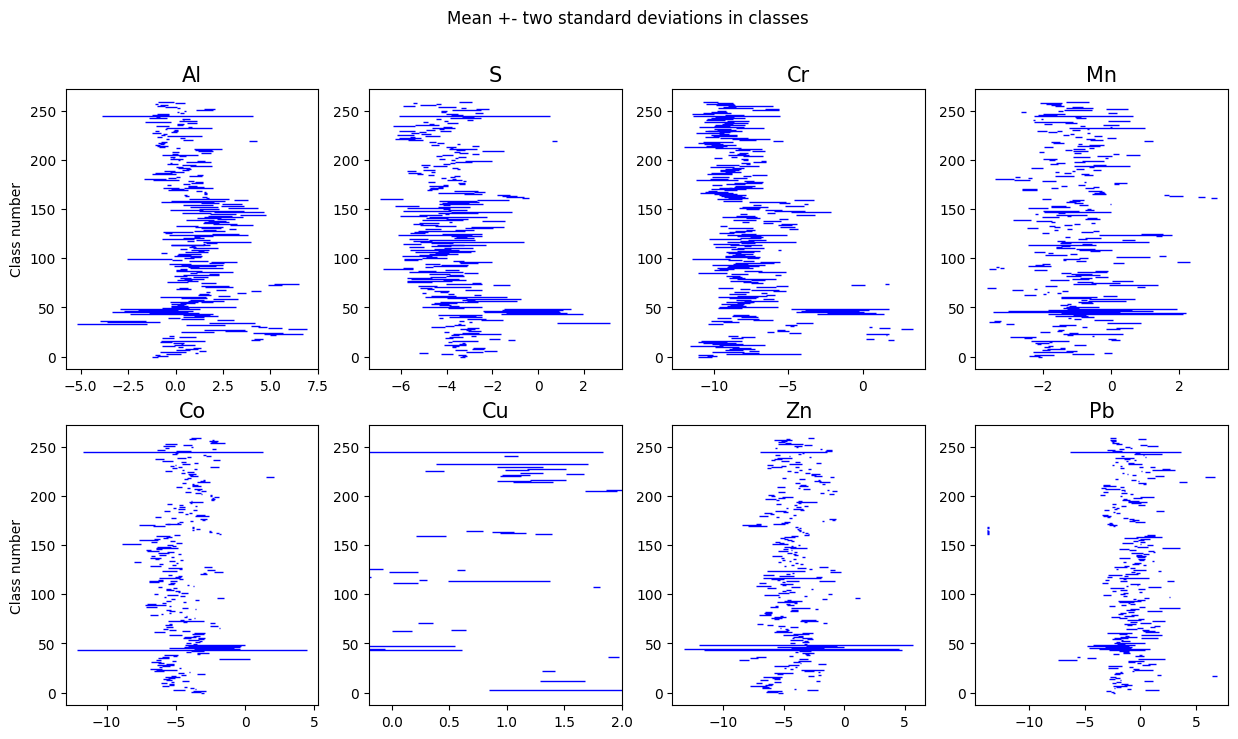

In [67]:
fig, ax = plt.subplots(2,4, figsize=(15,8))
plt.suptitle('Mean +- two standard deviations in classes')
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
                  xmax=upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
        ax[element//4][element%4].set_title(elements_names[element], size=15)
        if element == 5:
            ax[element//4][element%4].set_xlim([-0.2, 2.0])
        if element == 0 or element == 4:
            ax[element//4][element%4].set_ylabel('Class number')
#plt.savefig(figures_path + 'intervals.png', dpi=300)

### Visualisations of min-max intervals

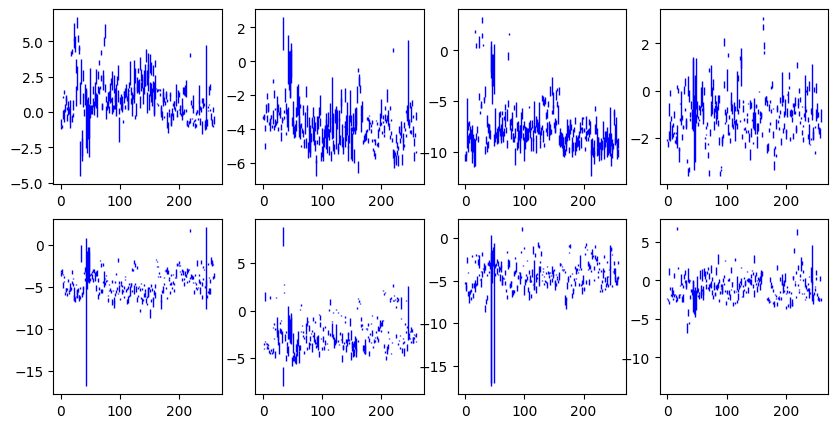

In [68]:
fig, ax = plt.subplots(2,4, figsize=(10,5))
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

For a single element:

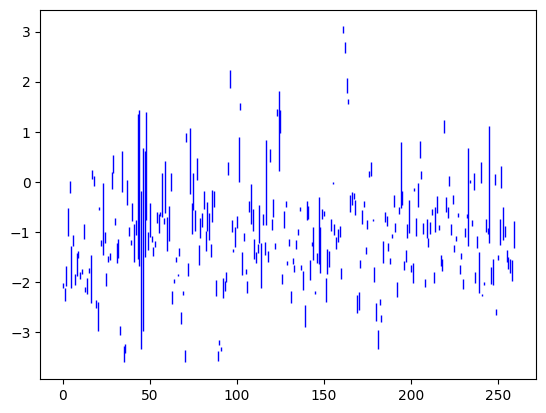

In [69]:
element = 3
for sample_id in range(min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

## Interpretability